In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib widget

import spikeinterface.full as si
from probeinterface.plotting import plot_probe
from spikeinterface_gui import run_mainwindow
si.set_global_job_kwargs(n_jobs=24) #Set to 24 cores to match my hardware, will need to be adapted to your hardware

In [2]:
#Load data path and data

path_to_data_folder = r"C:\Users\moffi\Documents\UCL\SWC\OSSS\Hackathon data\ses-001_date-04032026_g0_imec0"

recording = si.read_spikeglx(
    path_to_data_folder,
    stream_id="imec0.ap"
)

In [3]:
#Check recording loaded

print(recording)

SpikeGLXRecordingExtractor: 384 channels - 30.0kHz - 1 segments - 5,229,651 samples 
                            174.32s (2.91 minutes) - int16 dtype - 3.74 GiB


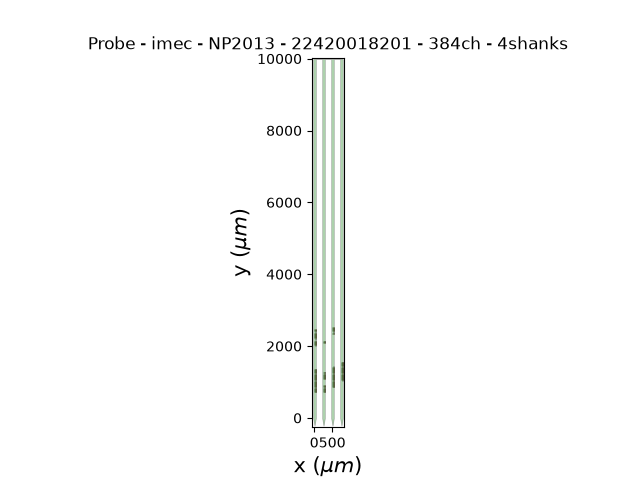

In [4]:
#Visualise the probe

probe = recording.get_probe()

plot_probe(probe)
plt.show()

In [5]:
#Visulaise the raw data

start_time = recording.get_times()[0]

si.plot_traces(
    recording,
    time_range=(start_time, start_time + 0.2),
    return_in_uV=True,
    order_channel_by_depth=True,
    backend="ipywidgets",
)

AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

In [6]:
##Preprocess the data
#Split data by shanks
#Check for phase shift
#Apply bandpass filter to remove noise
#Apply common reference filter to remove common mode noise (IMPORTANT: This needs to be done shank by shank)

split_recording = recording.split_by("group")

phase_shift_recording = si.phase_shift(split_recording)

filtered_recording = si.bandpass_filter(
    phase_shift_recording, freq_min=300, freq_max=6000
)

cmr_recording = si.common_reference(
    filtered_recording, operator="median"
)

print(phase_shift_recording)
print(filtered_recording)
print(cmr_recording)

{0: PhaseShiftRecording: 148 channels - 30.0kHz - 1 segments - 5,229,651 samples 
                     174.32s (2.91 minutes) - int16 dtype - 1.44 GiB, 1: PhaseShiftRecording: 60 channels - 30.0kHz - 1 segments - 5,229,651 samples 
                     174.32s (2.91 minutes) - int16 dtype - 598.49 MiB, 2: PhaseShiftRecording: 104 channels - 30.0kHz - 1 segments - 5,229,651 samples 
                     174.32s (2.91 minutes) - int16 dtype - 1.01 GiB, 3: PhaseShiftRecording: 72 channels - 30.0kHz - 1 segments - 5,229,651 samples 
                     174.32s (2.91 minutes) - int16 dtype - 718.18 MiB}
{0: BandpassFilterRecording: 148 channels - 30.0kHz - 1 segments - 5,229,651 samples 
                         174.32s (2.91 minutes) - int16 dtype - 1.44 GiB, 1: BandpassFilterRecording: 60 channels - 30.0kHz - 1 segments - 5,229,651 samples 
                         174.32s (2.91 minutes) - int16 dtype - 598.49 MiB, 2: BandpassFilterRecording: 104 channels - 30.0kHz - 1 segments - 5,229,6

In [7]:
#Plot preprocessed data

si.plot_traces(
    cmr_recording[0], #plots first shank
    time_range=(start_time, start_time + 0.2),
    return_in_uV=True,
    order_channel_by_depth=True,
    backend="ipywidgets" #Makes interactive plot
)

AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

In [20]:
#Spike sorting with KiloSort4

output_folder_KS = Path("kilosort4_output")

sorting_KS = si.run_sorter(
    "kilosort4",
    cmr_recording,
    folder=output_folder_KS,
    remove_existing_folder=True,
    do_CAR=False,
    highpass_cutoff=0.1,
    do_correction=False #Turns off drift correction because the recording is short
)

100%|██████████| 1/1 [00:04<00:00,  4.02s/it]


In [19]:
#Spike sorting with Lupin

output_folder_lup = Path("lupin_output")
sorter_params = {"apply_motion_correction": False}

sorting_LUPIN = si.run_sorter(
    "lupin",
    cmr_recording,
    folder=output_folder_lup,
    remove_existing_folder=True,
    verbose=True,
    **sorter_params
)


                            .::----::..
                 ..:-+#%*+#%@@@@@@@+..:+#+.
                .+@%%@@@@@@@@@@@@@@#:  .=@=
                -@@@@@@@@@@@@@@@@@@%-. .=@*
                .@@@@@@@@@@@@@@@@@@@*. .-%#
                 %@@@@@@@@@@@@@@@@@@*.  :#%
                 =%%@@@@@@@@@@@@@@%%+:  .+@.
                 -%#@@@@@@@@@@@@@@%*==  .-@.
                 :#%@@@@@@@@@@@@@@%#+#  .=@.
                 .+%@@@@@@@@@@@@@@@%#@. .+@.
                 .+*#@@@@@@@@@@@@@@@%@. .+@:
                 .=%+@@@@@@@@@@@@@@@@*.  =%-.
                  :#%##@@@@@@@@@@@@%%-.  :%+.
               ..:=**%@@@@@@@@@@@@@@@:.  .%%......
             .+#@%%%@**@%@@@@@@@@@@@*....=%@%@@@@@%=..
            .*@@@@@@@@@@@=#@@@@@@@@@@*=:.:.#@@@@@@%%-.
           .-%%@@@@@@@@@@@@@#+%@+-::-+=:=::+@@@@@@##-.
           .:%@@@@@@@@@@@@@@@@@%+%##*%%%**%@@@@@@##+.
            .+@@@@@@@@@@@@@@@@#***++***@@@@@@@@%%%=.
             .:*@@@@@@@@%=-.....   ....:-*%%%%%+-.
                 ..:-:..
                       

write_memory (no parallelization):   0%|          | 0/175 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

get protoype waveforms (no parallelization):   0%|          | 0/175 [00:00<?, ?it/s]

detect peaks (matched_filtering) (no parallelization):   0%|          | 0/175 [00:00<?, ?it/s]

...

find_clusters_from_peaks(): 66 cluster found


c:\Users\moffi\Documents\UCL\SWC\OSSS\Electrophysiology\course-ephys-osss\.venv\Lib\site-packages\spikeinterface\core\template_tools.py:397: UserWarning: get_template_peak_shift_on_main_channel() with Templates should provide a peak_sign
  warnings.warn("get_template_peak_shift_on_main_channel() with Templates should provide a peak_sign")


estimate_templates_with_accumulator (no parallelization):   0%|          | 0/175 [00:00<?, ?it/s]

find spikes (wobble) (no parallelization):   0%|          | 0/175 [00:00<?, ?it/s]

lupin run time 107.97s


In [22]:
#Load kilosort data

sorting_KS = si.load(Path("kilosort4_output"))
sorting_KS

{0: KiloSortSortingExtractor: 58 units - 1 segments - 30.0kHz,
 1: KiloSortSortingExtractor: 24 units - 1 segments - 30.0kHz,
 2: KiloSortSortingExtractor: 52 units - 1 segments - 30.0kHz,
 3: KiloSortSortingExtractor: 37 units - 1 segments - 30.0kHz}

In [23]:
#Load LUPIN data

sorting_LUPIN = si.load(Path("lupin_output"))
sorting_LUPIN

{0: NumpyFolder (NumpyFolderSorting): 105 units - 1 segments - 30.0kHz,
 1: NumpyFolder (NumpyFolderSorting): 60 units - 1 segments - 30.0kHz,
 2: NumpyFolder (NumpyFolderSorting): 90 units - 1 segments - 30.0kHz,
 3: NumpyFolder (NumpyFolderSorting): 63 units - 1 segments - 30.0kHz}

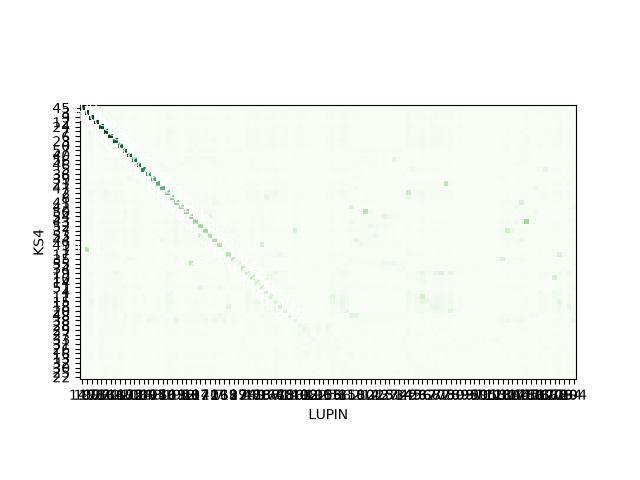

In [ ]:
#Compare sorter outputs

comparison = si.compare_two_sorters(sorting_KS[0], sorting_LUPIN[0], "KS4", "LUPIN") #Comparison has to be done shank by shank, here it is comparing shank 1
w = si.plot_agreement_matrix(comparison)

In [32]:
#Create KS4 sorting analyser

target_sorting_KS = sorting_KS

analyser_KS = si.create_sorting_analyzer(target_sorting_KS, cmr_recording)
print(analyser_KS)

estimate_templates (workers: 24 processes spawn):   0%|          | 0/175 [00:00<?, ?it/s]

estimate_templates (workers: 24 processes spawn):   0%|          | 0/175 [00:00<?, ?it/s]

estimate_templates (workers: 24 processes spawn):   0%|          | 0/175 [00:00<?, ?it/s]

estimate_templates (workers: 24 processes spawn):   0%|          | 0/175 [00:00<?, ?it/s]

SortingAnalyzer: 384 channels - 171 units - 1 segments - memory - sparse - has recording
Loaded 0 extensions


c:\Users\moffi\Documents\UCL\SWC\OSSS\Electrophysiology\course-ephys-osss\.venv\Lib\site-packages\spikeinterface\core\sortinganalyzer.py:262: FutureWarning: Passing sparsity and job arguments via keyword arguments will be deprecated in 0.106.0. Please pass them as a `sparsity_kwargs` or `job_kwargs` dictionary instead.
  return create_sorting_analyzer(


In [31]:
#Create LUPIN sorting analyser

target_sorting_LUPIN = sorting_LUPIN

analyser_lup = si.create_sorting_analyzer(target_sorting_LUPIN, cmr_recording)
print(analyser_lup)

estimate_templates (workers: 24 processes spawn):   0%|          | 0/175 [00:00<?, ?it/s]

estimate_templates (workers: 24 processes spawn):   0%|          | 0/175 [00:00<?, ?it/s]

estimate_templates (workers: 24 processes spawn):   0%|          | 0/175 [00:00<?, ?it/s]

estimate_templates (workers: 24 processes spawn):   0%|          | 0/175 [00:00<?, ?it/s]

SortingAnalyzer: 384 channels - 318 units - 1 segments - memory - sparse - has recording
Loaded 0 extensions


c:\Users\moffi\Documents\UCL\SWC\OSSS\Electrophysiology\course-ephys-osss\.venv\Lib\site-packages\spikeinterface\core\sortinganalyzer.py:262: FutureWarning: Passing sparsity and job arguments via keyword arguments will be deprecated in 0.106.0. Please pass them as a `sparsity_kwargs` or `job_kwargs` dictionary instead.
  return create_sorting_analyzer(


In [34]:
#Save analysers

KSanalyser_zarr = analyser_KS.save_as(format="zarr", folder=Path("KS4_analyser.zarr"))
LUPINanalyser_zarr = analyser_lup.save_as(format="zarr", folder=Path("LUPIN_analyser.zarr"))